In [1]:
from imutils import paths
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle
import random
import timeit

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input, BatchNormalization
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import losses
from tensorflow.keras import datasets, layers, models
import tensorflow as tf

import tensorflow_addons as tfa

from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.applications.xception import decode_predictions

2022-10-10 10:27:15.197573: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:

seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
print("[INFO]: Trying to Read the images")
#  Configure the Image Location
# 이미지 위치 구성하기
imagePaths = list(paths.list_images(r'/home/bishal/Research/Allergic-Rhinitis/Dataset/rotate'))

[INFO]: Trying to Read the images


In [4]:
#shuffle(imagePaths)
#imagePaths

In [5]:
len(imagePaths)
imagePaths[0].split(os.path.sep)[-1]

'28_1_00003_left.tif'

In [6]:
trainCount = 0
testCount =0
f = open("tmp.txt", "w")
for imagepath in imagePaths:
    if imagepath.split(os.path.sep)[-3] == "dataset4":
        testCount+=1
    else:
        trainCount+=1
  #  f.write(str(imagepath.split(os.path.sep)[-1])+"\n")
f.close()
totalCount = trainCount+testCount
print("trainCount-",trainCount)
print("testCount-", testCount)
print("totalCount", totalCount)

trainCount- 73
testCount- 17
totalCount 90


In [7]:
len(imagePaths)

90

In [8]:
from datetime import datetime
datetime.now().strftime('%H:%M:%S')

'10:27:15'

In [9]:
# Initialize data and labels
# 데이터 및 레이블 초기화/
data = []
labels = []
dirList= []

In [10]:
def cropImage(img):
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,thresholded = cv2.threshold(grayscale, 0, 255, cv2.THRESH_OTSU)
    #cv2.imwrite("otsu.png", thresholded)
    bbox = cv2.boundingRect(thresholded)
    x, y, w, h = bbox
    #print(bbox)
    croppedImg = img[y:y+h, x:x+w]
    return croppedImg

In [11]:
def resizeImage(img, size=(28,28)):

    h, w = img.shape[:2]
    c = img.shape[2] if len(img.shape)>2 else 1

    if h == w: 
        return cv2.resize(img, size, cv2.INTER_AREA)

    dif = h if h > w else w

    interpolation = cv2.INTER_AREA if dif > (size[0]+size[1])//2 else cv2.INTER_CUBIC

    x_pos = (dif - w)//2
    y_pos = (dif - h)//2

    if len(img.shape) == 2:
        mask = np.zeros((dif, dif), dtype=img.dtype)
        mask[y_pos:y_pos+h, x_pos:x_pos+w] = img[:h, :w]
    else:
        mask = np.zeros((dif, dif, c), dtype=img.dtype)
        mask[y_pos:y_pos+h, x_pos:x_pos+w, :] = img[:h, :w, :]

    return cv2.resize(mask, size, interpolation)

In [12]:
def cleanImage(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _ ,thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    circles = cv2.HoughCircles(thresh, cv2.HOUGH_GRADIENT, 1, 300, param1 = 250, param2 = 10, minRadius = 100, maxRadius = 1000)
    
    x, y, r = list(map(int, circles[0][0]))

    mask = np.zeros_like(img)
    mask = cv2.circle(mask, (x,y), r, (255,255,255), -1)
    # Apply mask
    res = np.zeros_like(img)
    res[(mask > 0)] = img[(mask > 0)]
    return res

In [13]:
# Formatting data and labels
for imagePath in imagePaths:
    # Extract the class label from file name and append to labels
    # 파일 이름에서 클래스 레이블을 추출하고 레이블에 추가함
    label = imagePath.split(os.path.sep)[-2]
    #if label=="2":
     #   labels.append("1")
    #else:
     #   labels.append(label)
    labels.append(label)
    # Load the image, swap color channels, and resize it to be a fixed 224x224 pixels while ignoring the aspect ratio
    # 이미지를 로드하고, 컬러 채널을 스왑하고, 가로 세로 비율을 무시하고 고정 224x224 픽셀로 크기를 조정함
    image = cv2.imread(imagePath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    #print(len(image))

    
    #image = cleanImage(image)
    #print(image.shape)
    #print("############")
    image = cropImage(image)
    #print(min(image.shape), "-", max(image.shape)
    # Cropping and resize should be done together for model execution. cos crop gives inconsistent data size
    image = cv2.resize(image, (224,224))
    # Append to data
    # 데이터에 추가
    data.append(image)

# Convert the data and labels to NumPy arrays while scaling the pixel intensities to the range [0,1]
# 픽셀 강도를 [0,1] 범위로 조정하면서 데이터와 레이블을 NumPy 배열로 변환
data = np.array(data) / 255.0
labels = np.array(labels)

In [14]:



labels.shape

(90,)

In [15]:
labels

array(['1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '2',
       '2', '2', '2', '2', '2', '1', '1', '1', '0', '0', '0', '0', '0',
       '0', '0', '0', '2', '2', '2', '2', '2', '2', '1', '1', '1', '1',
       '0', '0', '0', '0', '0', '0', '0', '0', '0', '2', '2', '2', '2',
       '2', '2', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0',
       '0', '2', '2', '2', '2', '2', '2', '1', '1', '1', '0', '0', '0',
       '0', '0', '0', '0', '0', '0', '2', '2', '2', '2', '2', '2'],
      dtype='<U1')

In [16]:
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights

array([0.68181818, 1.875     , 1.        ])

In [17]:
data[0].shape

(224, 224, 3)

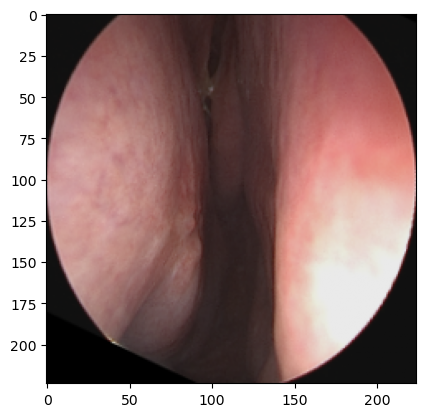

In [18]:
plt.imshow(data[7])

In [19]:
# Perform the one-hot encoding on the labels
# 레이블에 대해 원핫 인코딩 수행
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
#labels = to_categorical(labels, 3); 
print(labels)

[[0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]]


In [20]:
# Initialize the training data augmentation
# 교육 데이터 억멘테이션 초기화
trainAug = ImageDataGenerator(zoom_range=0.15, rotation_range=2, width_shift_range=0.2, height_shift_range=0.2,
		shear_range=0.15,fill_mode="constant", horizontal_flip=True)

In [21]:
data.shape

(90, 224, 224, 3)

In [22]:
# Partition the data into training and testing splits using 80% of the training data and the remaining 20% for testing
# 교육 데이터의 80%, 테스트에 20%를 사용하여 데이터를 교육 및 테스트 분할로 분할
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=19)

In [23]:
# Load the network, ensuring the Head-FC layer sets are left off
# Head-FC 레이어 세트가 포함되지 않도록 네트워크를 로드한다
baseModel = Xception(weights="imagenet", include_top=False, input_tensor=Input(shape=data[0].shape))

2022-10-10 10:27:16.296012: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-10-10 10:27:16.296561: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2022-10-10 10:27:16.339201: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-10 10:27:16.339371: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA TITAN RTX computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 23.65GiB deviceMemoryBandwidth: 625.94GiB/s
2022-10-10 10:27:16.339391: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2022-10-10 10:27:16.340292: I tensorflow/stream_executor/platform/default/d

In [24]:
%%script false --no-raise-error
model = models.Sequential()

model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",kernel_initializer="glorot_uniform",input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",kernel_initializer="glorot_uniform"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu",kernel_initializer="glorot_uniform"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation="relu",kernel_initializer="normal"))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(layers.Dense(3,activation="softmax"))

In [25]:
%%script false --no-raise-error
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
model = models.Sequential()
model.add(Conv2D(32,(3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = 'same',input_shape = (224,224,3)))
model.add(Conv2D(32,(3,3),activation = 'relu', kernel_initializer= 'he_uniform',padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = 'same'))
model.add(Conv2D(64,(3,3),activation = 'relu', kernel_initializer= 'he_uniform',padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = 'same'))
model.add(Conv2D(128,(3,3),activation = 'relu', kernel_initializer= 'he_uniform',padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(256,(3,3), activation = 'relu', kernel_initializer= 'he_uniform', padding = 'same'))
model.add(Conv2D(256,(3,3),activation = 'relu', kernel_initializer= 'he_uniform',padding = 'same'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128,activation= 'relu',kernel_initializer='he_uniform'))
model.add(Dense(3,activation = 'softmax', kernel_initializer="glorot_uniform" , name = 'classifier'))

In [26]:
from tf_siren import SinusodialRepresentationDense

In [27]:
# Construct the head model that will be placed on the top of the base model
# 보디 모델의 맨 위에 배치할 헤드 모델 구성
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4,4))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = SinusodialRepresentationDense(64, activation='sine', w0=1.0)(headModel)
#headModel = Dense(64, activation=tf.keras.layers.LeakyReLU(alpha=0.01))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(3, activation="softmax")(headModel)

In [28]:
%%script false --no-raise-error
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D

headModel = baseModel.output 
headModel = MaxPool2D(pool_size = (2, 2))(headModel)
headModel = Conv2D(64, kernel_size=(3, 3),padding = 'Same',input_shape=data[0].shape,
                     activation= "relu", kernel_initializer = 'glorot_uniform') (headModel)
headModel = MaxPool2D(pool_size = (2, 2))(headModel)
headModel = Dropout(0.25)(headModel)

headModel = Conv2D(64, kernel_size=(3, 3),padding = 'Same', 
                 activation ="relu", kernel_initializer = 'glorot_uniform') (headModel)
headModel = MaxPool2D(pool_size = (2, 2))(headModel)
headModel = Dropout(0.25)(headModel)


headModel = Flatten()(headModel)
headModel = Dense(128, activation='relu', kernel_initializer="normal")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(3, activation='softmax')(headModel)

In [29]:
%%script false --no-raise-error
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
headModel = baseModel.output
headModel = Conv2D(128, kernel_size=(3, 3),padding = 'Same',input_shape=data[0].shape,
                     activation= "relu", kernel_initializer = 'glorot_uniform') (headModel)
headModel = MaxPool2D(pool_size = (3, 3))(headModel)
headModel = Flatten()(headModel)

headModel = Dense(64, activation='relu', kernel_initializer="normal")(headModel)
headModel = Dropout(0.3)(headModel)
headModel = Dense(32, activation='relu', kernel_initializer="normal")(headModel)
headModel = Dropout(0.25)(headModel)
headModel = Dense(3, activation='softmax')(headModel)

In [30]:
# Place the Head-FC model on top of the Base model - This become the actual model that we will train
# Head-FC 모델을 보디 모델 위에 배치한다. 이것이 우리가 교육할 실제 모델이 될 것이다.
model = Model(inputs=baseModel.input, outputs=headModel)

In [31]:
# Make sure that the basemodel layers will not be trained and only head model will be trained.
# 보디 모델 레이어가 훈련되지 않고 헤드 모델만 훈련되는지 확인한다.
for layer in baseModel.layers:
    layer.trainable = False

In [32]:
trainX.shape

(72, 224, 224, 3)

In [33]:
#labels

In [34]:
trainY.shape

(72, 3)

In [35]:
# Set the hyper-parameters
# 하이퍼 파라미터 설정
# INIT_LR = 1e-3
INIT_LR = 0.001
EPOCHS = 200
BS = 8

In [36]:
True# Compile the Model
# 모델 컴파일
opt = Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss=tfa.losses.SigmoidFocalCrossEntropy(), optimizer=opt, metrics=["accuracy"])

In [37]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience=5, 
                                            verbose=1, 
                                            factor=0.2, 
                                            min_lr=1e-8)

from tensorflow.keras.callbacks import EarlyStopping

custom_early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=95,
    restore_best_weights=True
)

In [38]:
type(trainX[0])

numpy.ndarray

In [39]:
# Train the Network Model
# 모델 교육
print("[INFO] Model Training")
start = timeit.default_timer()
H = model.fit(
        trainAug.flow(trainX, trainY, batch_size=BS),
        steps_per_epoch=len(trainX) // BS,
        validation_data=(testX, testY),
        validation_steps=len(testX) // BS,
        class_weight=dict(enumerate(class_weights)),
        epochs=EPOCHS,
        callbacks=[custom_early_stopping])

[INFO] Model Training
Epoch 1/200


2022-10-10 10:27:17.906603: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2022-10-10 10:27:17.923154: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 3693010000 Hz
2022-10-10 10:27:19.158265: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2022-10-10 10:27:19.289554: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7


9/9 [==============================] - 3s 141ms/step - loss: 0.4320 - accuracy: 0.3182 - val_loss: 0.1298 - val_accuracy: 0.7222
Epoch 2/200
9/9 [==============================] - 0s 49ms/step - loss: 0.2938 - accuracy: 0.4422 - val_loss: 0.1609 - val_accuracy: 0.6111
Epoch 3/200
9/9 [==============================] - 0s 48ms/step - loss: 0.3370 - accuracy: 0.3935 - val_loss: 0.1938 - val_accuracy: 0.6111
Epoch 4/200
9/9 [==============================] - 0s 48ms/step - loss: 0.2453 - accuracy: 0.5494 - val_loss: 0.1852 - val_accuracy: 0.6111
Epoch 5/200
9/9 [==============================] - 0s 49ms/step - loss: 0.3003 - accuracy: 0.4607 - val_loss: 0.2293 - val_accuracy: 0.5000
Epoch 6/200
9/9 [==============================] - 0s 49ms/step - loss: 0.3989 - accuracy: 0.4231 - val_loss: 0.1415 - val_accuracy: 0.5556
Epoch 7/200
9/9 [==============================] - 0s 51ms/step - loss: 0.4790 - accuracy: 0.5206 - val_loss: 0.1480 - val_accuracy: 0.6667
Epoch 8/200
9/9 [==============

In [40]:
stop = timeit.default_timer()
print('Total Training Time: ', stop - start) 

Total Training Time:  54.4341588979878


In [41]:
trainX.shape

(72, 224, 224, 3)

In [42]:
trainY.shape

(72, 3)

In [43]:
testX[:1].shape

(1, 224, 224, 3)

In [44]:
# Make predictions on the testing set
# 테스트 세트에서 예측한다
print("Making Predictions on the Test Set")
predIdxs = model.predict(testX, batch_size=BS)
preds = predIdxs
predIdxs = np.argmax(predIdxs, axis=1)
print("Classification Report")
print(classification_report(testY.argmax(axis=1), predIdxs, target_names=lb.classes_))

Making Predictions on the Test Set
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.75      1.00      0.86         3
           2       0.71      0.83      0.77         6

    accuracy                           0.83        18
   macro avg       0.82      0.87      0.83        18
weighted avg       0.86      0.83      0.84        18



In [45]:
testX.shape

(18, 224, 224, 3)

In [46]:
#Voting Implementation

In [47]:
# Image Generator
dataGenArgs = dict(rotation_range=2,

                    zoom_range=0.1,
                    fill_mode='constant')
dataGen = ImageDataGenerator(**dataGenArgs)

In [48]:
np.array( [testX[1]]).shape

(1, 224, 224, 3)

In [49]:
testY.argmax(axis=1)

array([0, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 2, 0, 0, 1, 2, 0, 2])

In [50]:
i4 = model.predict(np.array([testX[4]]), batch_size=BS)
i4

array([[0.09199602, 0.52356946, 0.38443458]], dtype=float32)

In [51]:
testX.shape

(18, 224, 224, 3)

In [52]:
predIdxs

array([0, 0, 0, 2, 1, 0, 0, 2, 2, 1, 1, 2, 0, 2, 1, 2, 0, 2])

In [53]:
votingSize= 100
votedY = []
for i in range(len(testX)):
    # Augment a single image into VotingSize images
    iterGen = dataGen.flow(np.array([testX[i]]), np.array([testY[i]]), batch_size=1, seed=1)
    (genX, genY) = ([], [])

    # init Vote counter
    voteCounter = {}
    voteCounter[0] = 0
    voteCounter[1] = 0
    voteCounter[2] = 0
    for i in range(votingSize):
        X, Y = iterGen.next()
        genX.append(X[0])
        genY.append(Y[0])

    genX = np.array(genX)
    genY = np.array(genY)
    #plt.imshow(genX[6])
    
    # perform Predition on images
    preds = model.predict(genX, batch_size=BS)
    preds = np.argmax(preds, axis=1)
    # Votes Selection
    for vote in preds:
        if vote==0:
            voteCounter[0] += 1
        elif vote==1:
            voteCounter[1] += 1
        elif vote==2:
            voteCounter[2] += 1
    
    # getting Voting Results
    res = list(voteCounter.values())
    #print(res)
    voted = np.array(res).argmax()
    votedY.append(voted)
votedY = np.array(votedY)

In [54]:
votedY

array([0, 0, 0, 2, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 1, 2, 0, 2])

In [55]:
testY.argmax(axis=1)

array([0, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 2, 0, 0, 1, 2, 0, 2])

In [56]:
predIdxs

array([0, 0, 0, 2, 1, 0, 0, 2, 2, 1, 1, 2, 0, 2, 1, 2, 0, 2])

In [57]:
print("Classification Report")
print(classification_report(testY.argmax(axis=1), votedY, target_names=lb.classes_))

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.75      1.00      0.86         3
           2       0.56      0.83      0.67         6

    accuracy                           0.72        18
   macro avg       0.77      0.80      0.75        18
weighted avg       0.81      0.72      0.72        18



In [58]:
genY.argmax(axis=1)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [59]:
values, counts = np.unique(predIdxs, return_counts=True)
print(values)

print(np.array(counts).argmax())

[0 1 2]
0


In [60]:
#preds

In [61]:
len(predIdxs)

18

In [62]:
# Compute Confusion Matrix and derrive raw, accuracy, sensitivity, specificity from it
# 혼란 매트릭스
cm= confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0,0] + cm[1,1] +cm[2,2]) / total

sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
# 혼란 매트릭스 보기
print("Confusion Matrix and its Derrivatives")
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

Confusion Matrix and its Derrivatives
[[7 0 2]
 [0 3 0]
 [0 1 5]]
acc: 0.8333
sensitivity: 1.0000
specificity: 1.0000


In [63]:
acc = (cm[0,0] + cm[1,1] + cm[2,2]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1] + cm[0,2])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1] + cm[1,2])
specificity2 = cm[2, 2] / (cm[2, 0] + cm[2, 1] + cm[2,2])
specificity = (specificity + specificity2) / 2
print(acc)
print(sensitivity)
print(specificity)

0.8333333333333334
0.7777777777777778
0.9166666666666667


In [64]:
f = open("tmp.txt", "w")

for acc in H.history["val_accuracy"]:
    f.write(str((acc*100)//1)+"\n")
f.close()

In [65]:
len(H.history["loss"])

109

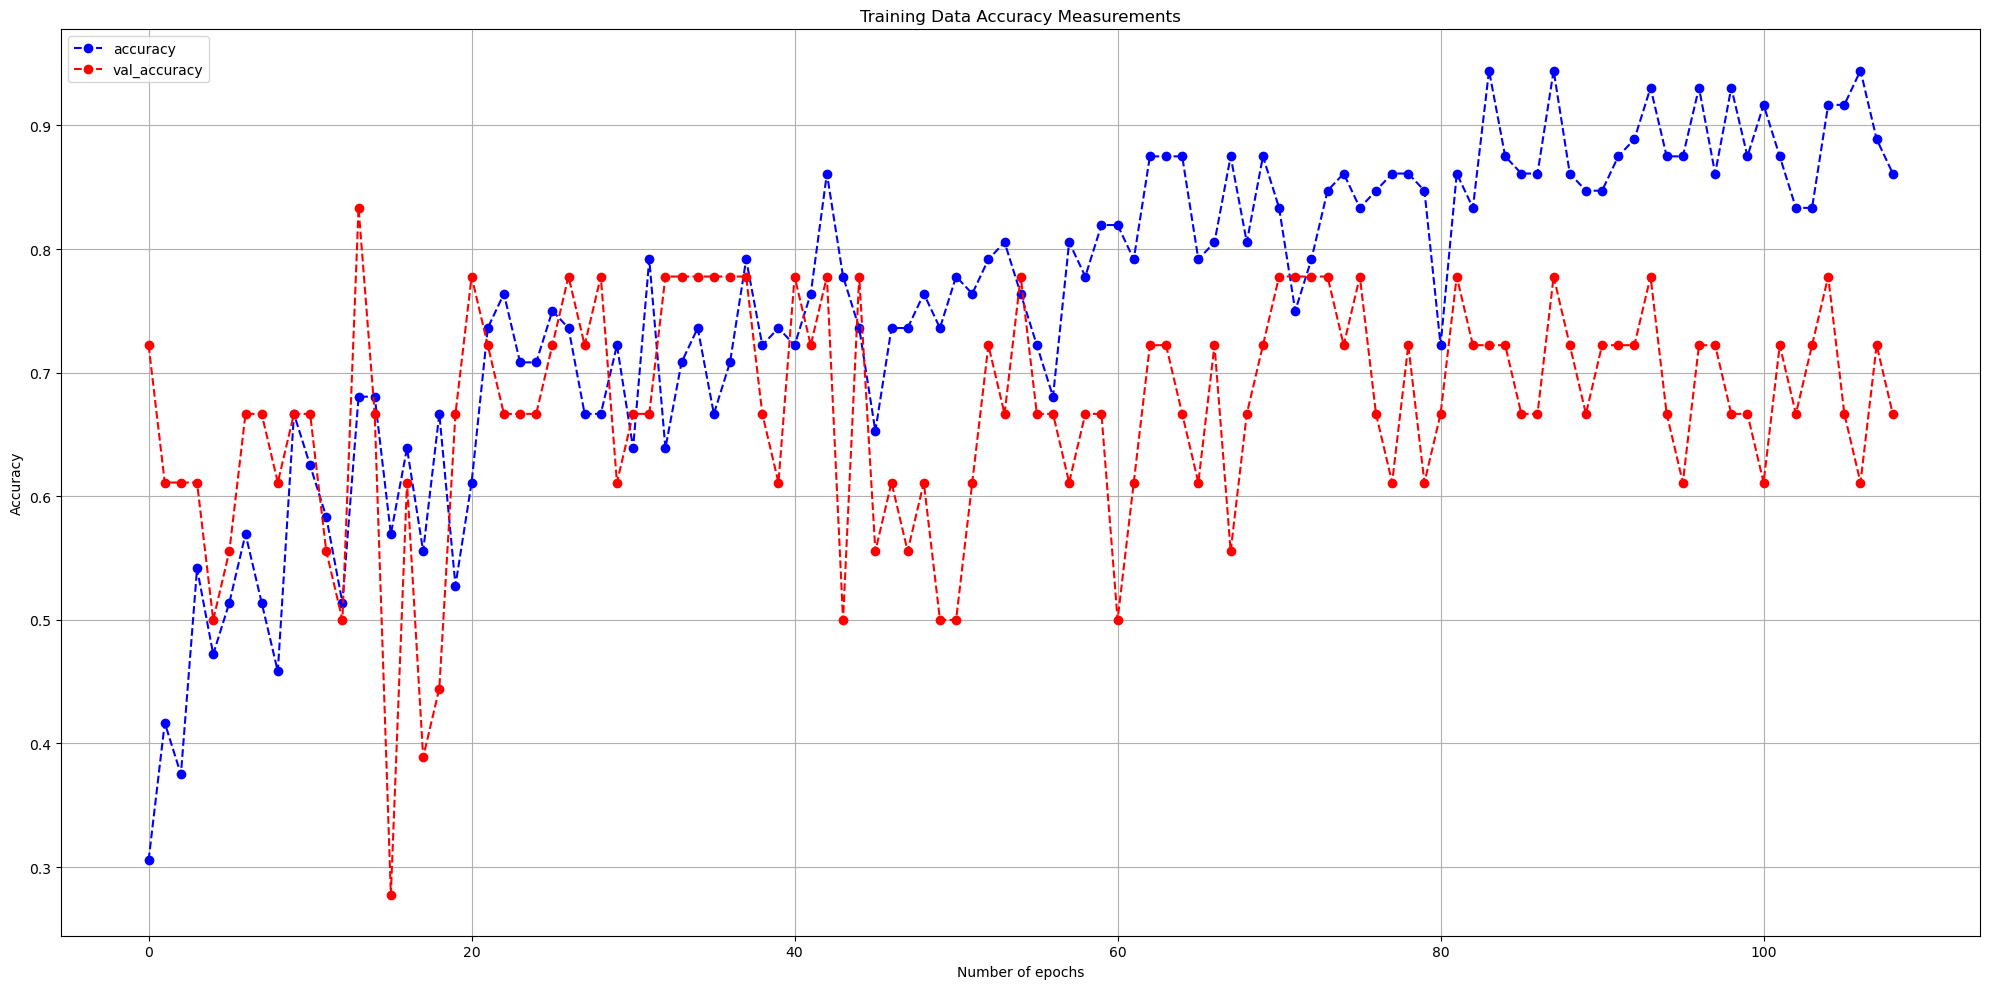

In [66]:
def accuracy(history):
    fig = plt.figure(figsize=(20,10))
    
    
    plt.plot(history.history["accuracy"], 'bo--', label="accuracy")
    plt.plot(history.history['val_accuracy'], 'ro--', label="val_accuracy")
    plt.title("Training Data Accuracy Measurements")
    plt.xlabel("Number of epochs")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
accuracy(H)

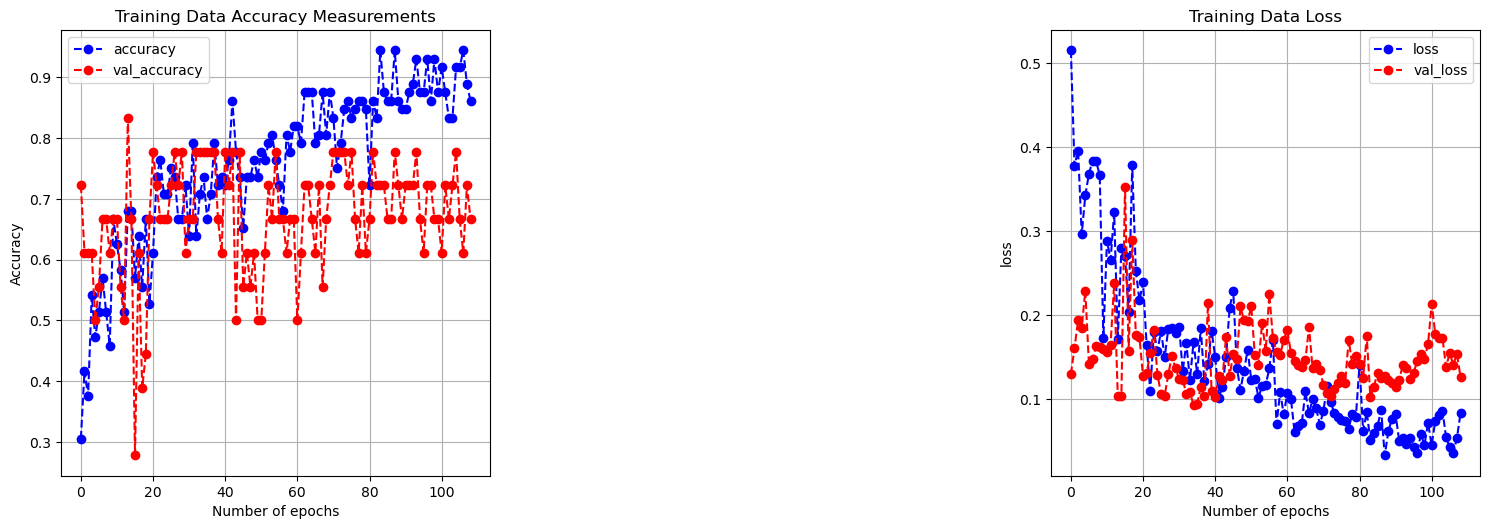

In [67]:
def accuracy_lr_loss_plot (history):
    fig = plt.figure(figsize=(15,10))
    
    plt.subplot(231)
    plt.plot(history.history["accuracy"], 'bo--', label="accuracy")
    plt.plot(history.history['val_accuracy'], 'ro--', label="val_accuracy")
    plt.title("Training Data Accuracy Measurements")
    plt.xlabel("Number of epochs")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    '''  
    plt.subplot(232)
    plt.plot(history.history['lr'], 'go--', label="Learning Rate")
    plt.title("Learning Rate")
    plt.xlabel("Number of epochs")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    '''
    
    
    plt.subplot(233)
    plt.plot(history.history["loss"], "bo--", label="loss")
    plt.plot(history.history["val_loss"], "ro--", label = "val_loss")
    plt.title("Training Data Loss")
    plt.xlabel("Number of epochs")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    plt.show()
accuracy_lr_loss_plot(H)

Final Plot Generated.


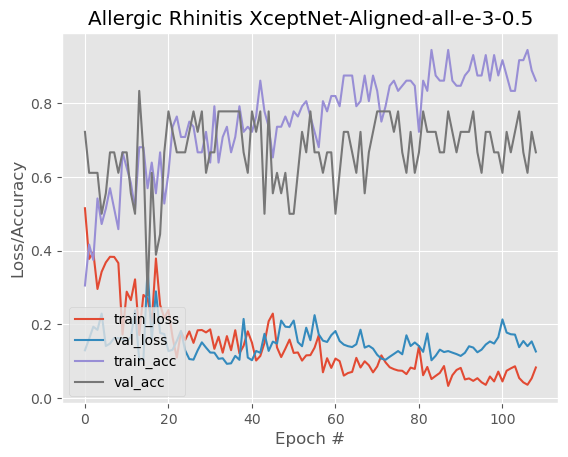

In [68]:




# plot the training loss and accuracy
# 플롯 그래프
print("Final Plot Generated.")
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Allergic Rhinitis XceptNet-Aligned-all-e-3-0.5")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig("[iter-3] [XCEPTN] plot,rotate-1e3")

In [69]:
scores = model.evaluate(testX, testY, verbose=1)
cvscores = []
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
cvscores.append(scores[1] * 100)

1/1 [==============================] - 1s 550ms/step - loss: 0.1036 - accuracy: 0.8333
accuracy: 83.33%


In [70]:
print("%.2f%% (+/- %.2f%%)" % (np.max(H.history['val_accuracy']), np.std(H.history['val_accuracy'])))

0.83% (+/- 0.09%)


model.output_shape # model summary representation
model.summary() # model configuration
model.get_config() # list all weight tensors in the model

In [71]:
model.output_shape

(None, 3)

In [72]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
block1_conv1 (Conv2D)           (None, 111, 111, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
block1_conv1_bn (BatchNormaliza (None, 111, 111, 32) 128         block1_conv1[0][0]               
__________________________________________________________________________________________________
block1_conv1_act (Activation)   (None, 111, 111, 32) 0           block1_conv1_bn[0][0]            
______________________________________________________________________________________________








model.summary()

In [73]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
block1_conv1 (Conv2D)           (None, 111, 111, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
block1_conv1_bn (BatchNormaliza (None, 111, 111, 32) 128         block1_conv1[0][0]               
__________________________________________________________________________________________________
block1_conv1_act (Activation)   (None, 111, 111, 32) 0           block1_conv1_bn[0][0]            
______________________________________________________________________________________________

In [74]:
preds

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [75]:
%%script false --no-raise-error
model.save("ARhinitisModel", save_format="h5")
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

In [12]:
with open('ARStats.csv', 'r') as f:
    last_line = f.readlines()[-2].split(",")[0]
    intLine = int(last_line)
intLine

59

In [14]:
import os
cwd = os.getcwd()
cwd

'/home/bishal/Research/Allergic-Rhinitis'